In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [6]:
#  Load the dataset (Make sure you upload the CSV file to your environment first)
df = pd.read_csv('/WA_Fn-UseC_-Telco-Customer-Churn.csv')

#  Print structural details (data types, entry count, memory usage)
print("--- DATASET STRUCTURAL INFO ---")
df.info()

#  CRITICAL FIX: Convert 'TotalCharges' from text (object) to numeric (float).
# Brand new customers with 0 tenure have empty spaces " " in this column.
# 'errors=coerce' converts empty spaces to NaN, then we replace NaN with 0.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

#  Print statistical summary for numerical columns
print("\n--- STATISTICAL SUMMARY ---")
print(df.describe())

#  Check for any missing values across all columns
print("\n--- MISSING VALUE COUNT ---")
print(df.isnull().sum())


--- DATASET STRUCTURAL INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessB

In [7]:
#  Remove the customerID column since it contains unique identifiers with no predictive power
df.drop('customerID', axis=1, inplace=True)

#  Convert 'TotalCharges' from a text/object type to a decimal/float type
# 'errors=coerce' forces blank strings (" ") into NaN missing value tags
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

#  Permanently remove the rows containing those newly created NaN values
df.dropna(inplace=True)

#  Use LabelEncoder to convert all remaining text features into mathematical values
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

#  Print a quick status check to confirm data changes
print("--- PREPROCESSING COMPLETED ---")
print(f"Remaining Data Shape - Rows: {df.shape[0]}, Columns: {df.shape[1]}")


--- PREPROCESSING COMPLETED ---
Remaining Data Shape - Rows: 7043, Columns: 20


In [8]:
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [9]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

results = []

# Train and evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results.append((name, acc))

    print(f"\n📊 {name} Results:")
    print("Accuracy:", acc)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



📊 Logistic Regression Results:
Accuracy: 0.815471965933286
Confusion Matrix:
 [[934 102]
 [158 215]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.58      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409


📊 Decision Tree Results:
Accuracy: 0.7196593328601846
Confusion Matrix:
 [[834 202]
 [193 180]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.81      0.81      1036
           1       0.47      0.48      0.48       373

    accuracy                           0.72      1409
   macro avg       0.64      0.64      0.64      1409
weighted avg       0.72      0.72      0.72      1409


📊 Random Forest Results:
Accuracy: 0.7934705464868701
Confusion Matrix:
 [[945  91]
 [200 173]]
Cl

/tmp/ipykernel_1920/2865372706.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Accuracy", y="Model", palette="mako")


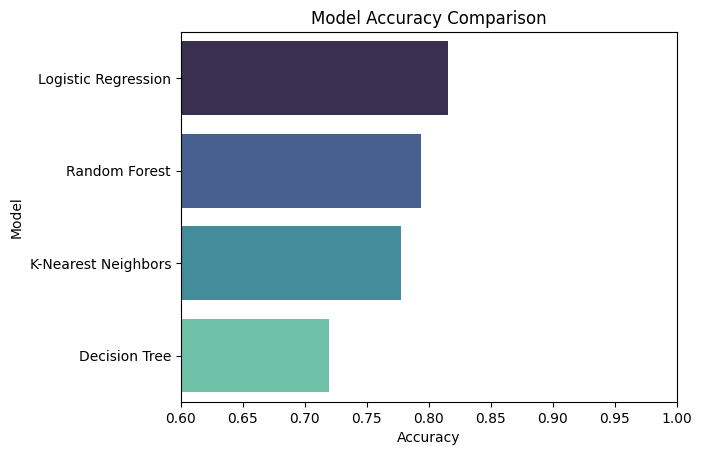

In [10]:
# Create results DataFrame
results_df = pd.DataFrame(results, columns=["Model", "Accuracy"]).sort_values(by="Accuracy", ascending=False)

# Plot
sns.barplot(data=results_df, x="Accuracy", y="Model", palette="mako")
plt.title("Model Accuracy Comparison")
plt.xlim(0.6, 1.0)
plt.show()


**VISUALIZATION**

/tmp/ipykernel_1920/3562221172.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')


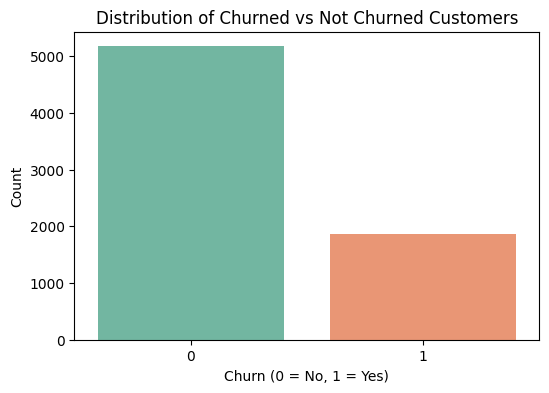

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Distribution of Churned vs Not Churned Customers')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()


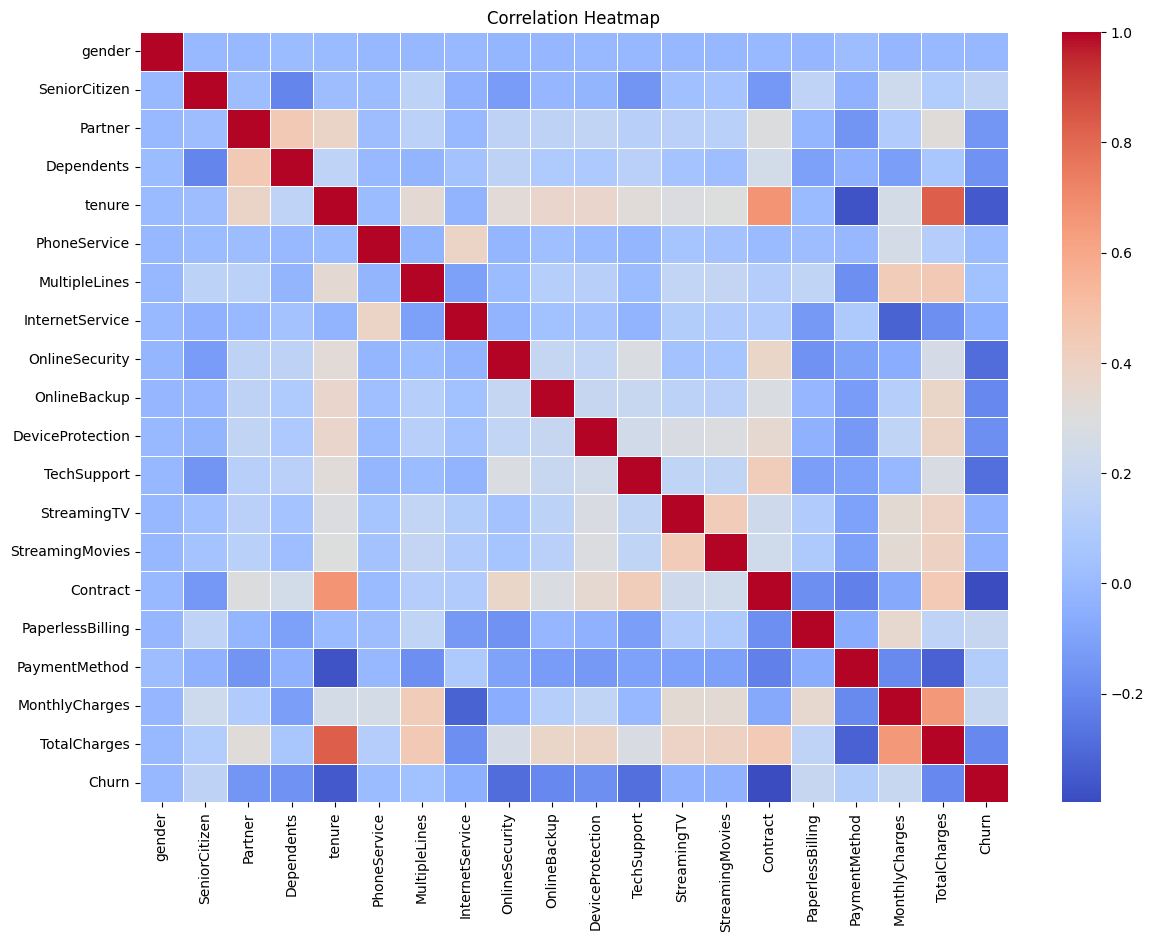

In [12]:
plt.figure(figsize=(14,10))
corr = df.corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


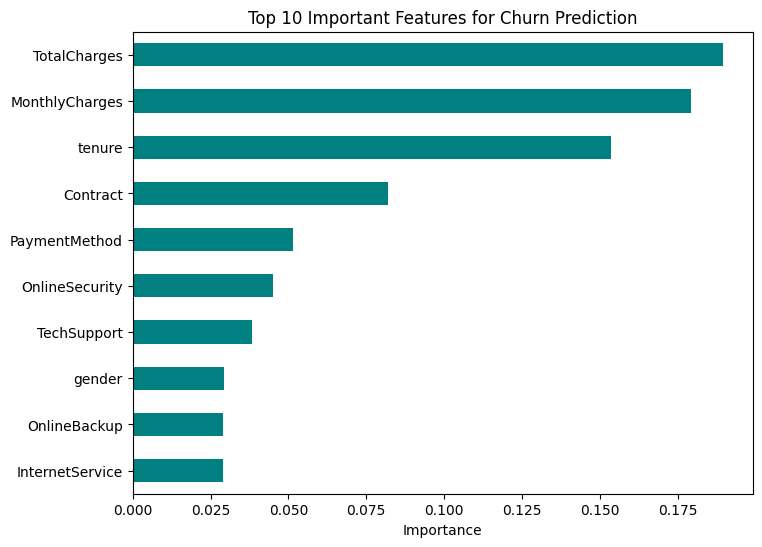

In [13]:
# Train Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

# Plot feature importances
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh', figsize=(8,6), color='teal')
plt.title('Top 10 Important Features for Churn Prediction')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.show()


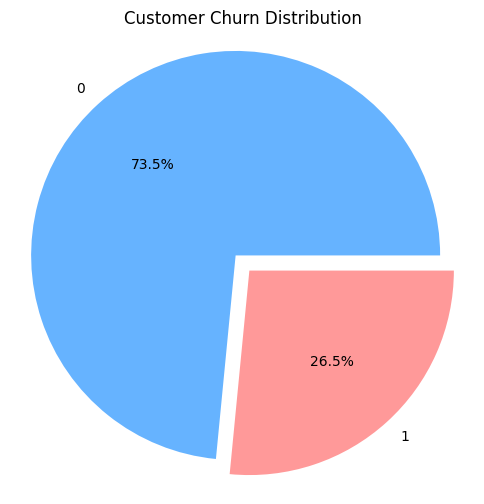

In [14]:
import matplotlib.pyplot as plt

# Pie chart for churn distribution
churn_counts = df['Churn'].value_counts()
labels = churn_counts.index
sizes = churn_counts.values
colors = ['#66b3ff','#ff9999']

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, explode=(0, 0.1))
plt.title('Customer Churn Distribution')
plt.axis('equal')
plt.show()



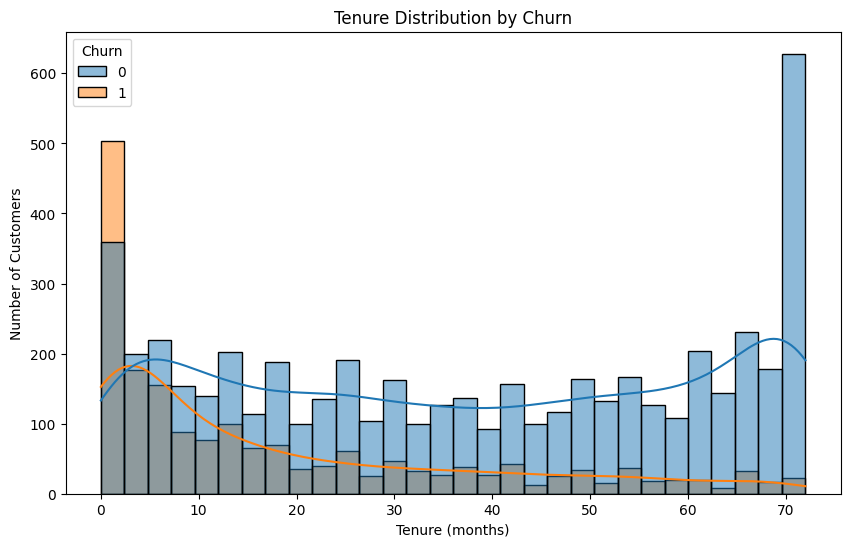

In [15]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True)
plt.title('Tenure Distribution by Churn')
plt.xlabel('Tenure (months)')
plt.ylabel('Number of Customers')
plt.show()


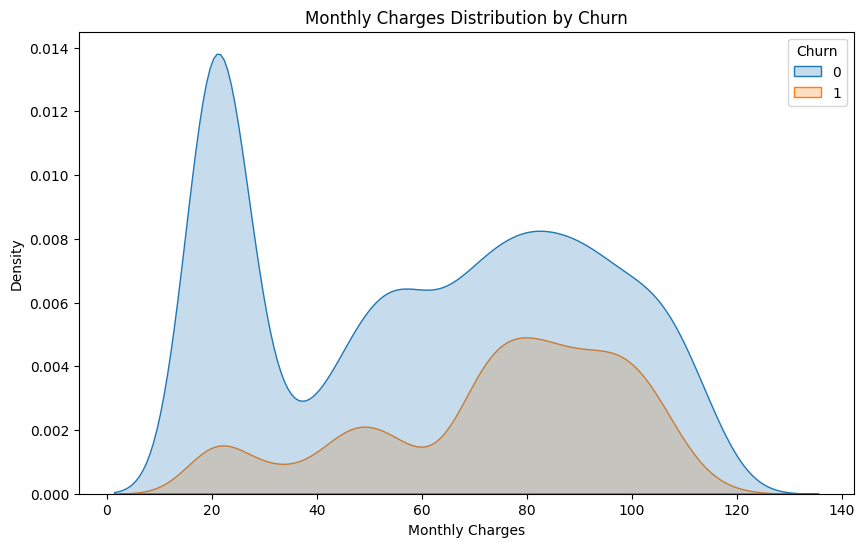

In [16]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x="MonthlyCharges", hue="Churn", fill=True)
plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Monthly Charges")
plt.ylabel("Density")
plt.show()


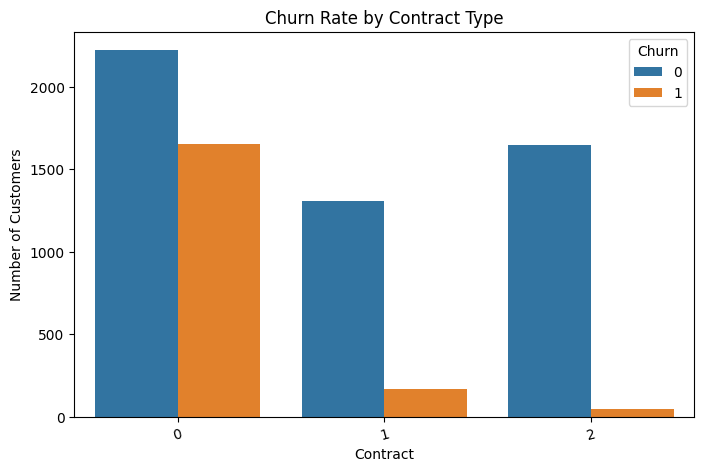

In [17]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn Rate by Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.show()


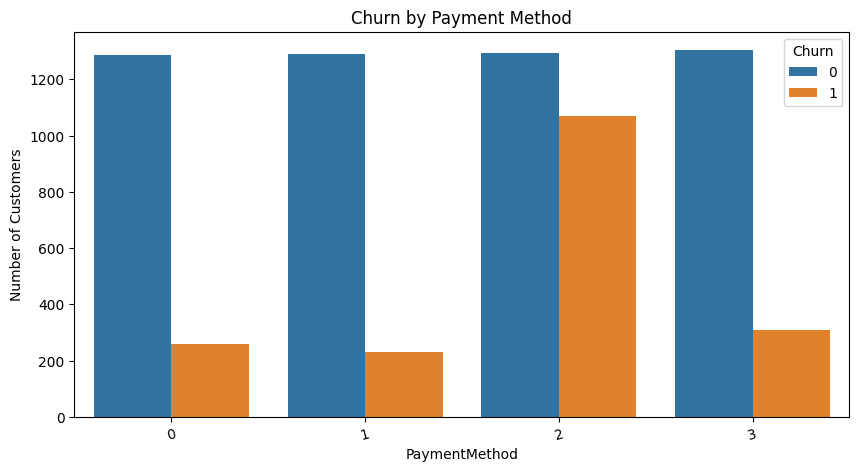

In [18]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="PaymentMethod", hue="Churn")
plt.title("Churn by Payment Method")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.show()


In [19]:
# Assuming 'y_pred' contains your model's 1/0 predictions
# and 'X_test' contains the corresponding 'MonthlyCharges' feature.

# Filter customers the model flagged as high-risk
predicted_churners_charges = X_test[y_pred == 1]['MonthlyCharges']

total_revenue_at_risk = predicted_churners_charges.sum()
print(f" Total Monthly Revenue at Risk: ${total_revenue_at_risk:,.2f}")

 Total Monthly Revenue at Risk: $21,993.20


In [20]:
# Identify customers flagged to churn who pay more than the median monthly charge
high_value_threshold = X_test['MonthlyCharges'].median()

high_value_at_risk = X_test[(y_pred == 1) & (X_test['MonthlyCharges'] > high_value_threshold)]

print(f" Number of High-Value Customers at Risk: {len(high_value_at_risk)}")

 Number of High-Value Customers at Risk: 215


In [21]:
# Business Assumptions
conversion_rate = 0.40  # 40% of targeted customers accept the offer and stay
discount_multiplier = 0.20  # 20% discount incentive offered

# Financial Calculations
revenue_saved = total_revenue_at_risk * conversion_rate
cost_of_incentives = total_revenue_at_risk * discount_multiplier
net_retention_roi = revenue_saved - cost_of_incentives

print(f" Estimated Net Retention Savings: ${net_retention_roi:,.2f}")

 Estimated Net Retention Savings: $4,398.64


/tmp/ipykernel_1920/444304525.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=financial_categories, y=financial_values, palette="Blues_r")


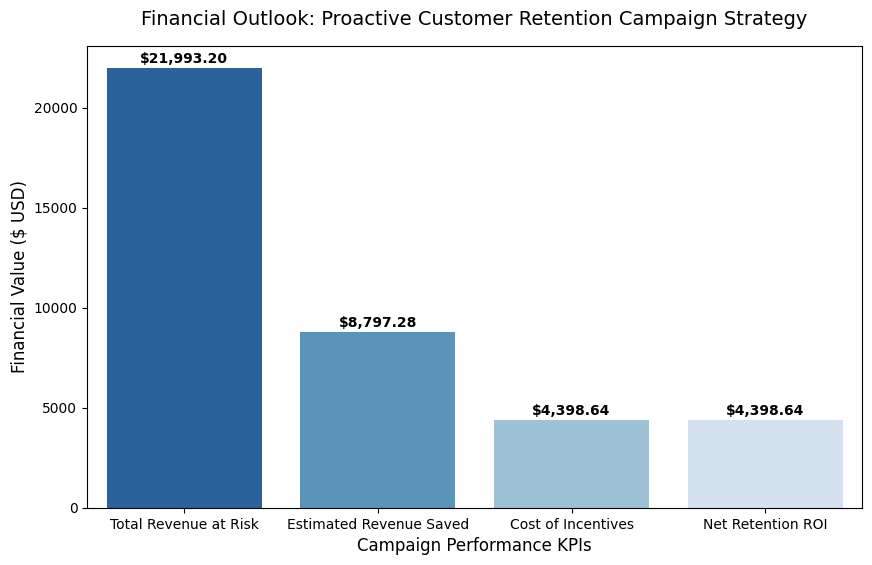

In [22]:
#  Define financial metrics computed from your business rules
financial_categories = ['Total Revenue at Risk', 'Estimated Revenue Saved', 'Cost of Incentives', 'Net Retention ROI']
financial_values = [total_revenue_at_risk, revenue_saved, cost_of_incentives, net_retention_roi]

#  Plot the business impact bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=financial_categories, y=financial_values, palette="Blues_r")

plt.title("Financial Outlook: Proactive Customer Retention Campaign Strategy", fontsize=14, pad=15)
plt.ylabel("Financial Value ($ USD)", fontsize=12)
plt.xlabel("Campaign Performance KPIs", fontsize=12)

# Add exact value labels on top of each bar
for i, val in enumerate(financial_values):
    plt.text(i, val + (max(financial_values) * 0.01), f"${val:,.2f}", ha='center', fontweight='bold')

plt.savefig('proactive_retention_campaign_roi.png')
plt.show()

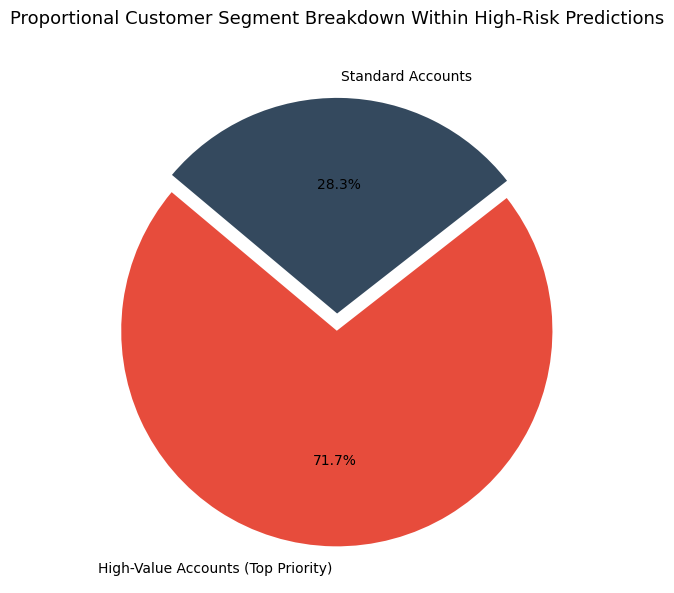

In [23]:
#  Segment customers in the test set flagged to churn
total_predicted_churners = len(predicted_churners_charges)
high_value_count = len(high_value_at_risk)
standard_value_count = total_predicted_churners - high_value_count

#  Build a proportional distribution pie chart
plt.figure(figsize=(7, 7))
plt.pie(
    [high_value_count, standard_value_count],
    labels=['High-Value Accounts (Top Priority)', 'Standard Accounts'],
    autopct='%1.1f%%',
    colors=['#e74c3c', '#34495e'],
    explode=(0.08, 0),
    startangle=140
)

plt.title("Proportional Customer Segment Breakdown Within High-Risk Predictions", fontsize=13, pad=15)
plt.savefig('predicted_churn_value_segments.png')
plt.show()

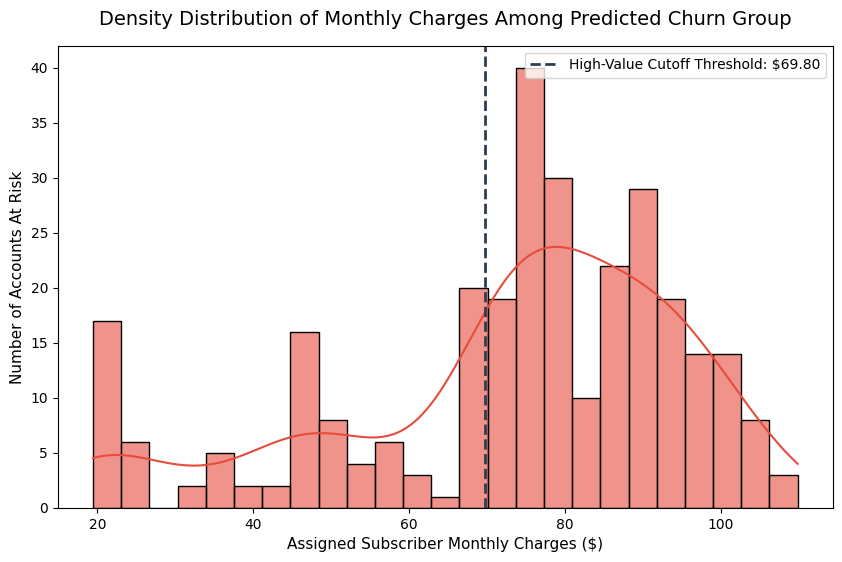

In [24]:
#  FINANCIAL VALUE ACCOUNT DISTRIBUTION MATRIX
plt.figure(figsize=(10, 6))

#  Overlay a distribution histogram for accounts flagged as churn risk
sns.histplot(predicted_churners_charges, bins=25, kde=True, color='#e74c3c', alpha=0.6)

# 2. Draw a line showing the High-Value account threshold
plt.axvline(high_value_threshold, color='#2c3e50', linestyle='--', linewidth=2,
            label=f'High-Value Cutoff Threshold: ${high_value_threshold:.2f}')

plt.title("Density Distribution of Monthly Charges Among Predicted Churn Group", fontsize=14, pad=15)
plt.xlabel("Assigned Subscriber Monthly Charges ($)", fontsize=11)
plt.ylabel("Number of Accounts At Risk", fontsize=11)
plt.legend(loc='upper right')

plt.savefig('monthly_charges_distribution_at_risk.png')
plt.show()

/tmp/ipykernel_1920/3614119103.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=contract_revenue_leakage, x='Contract', y='MonthlyCharges', palette='rocket')


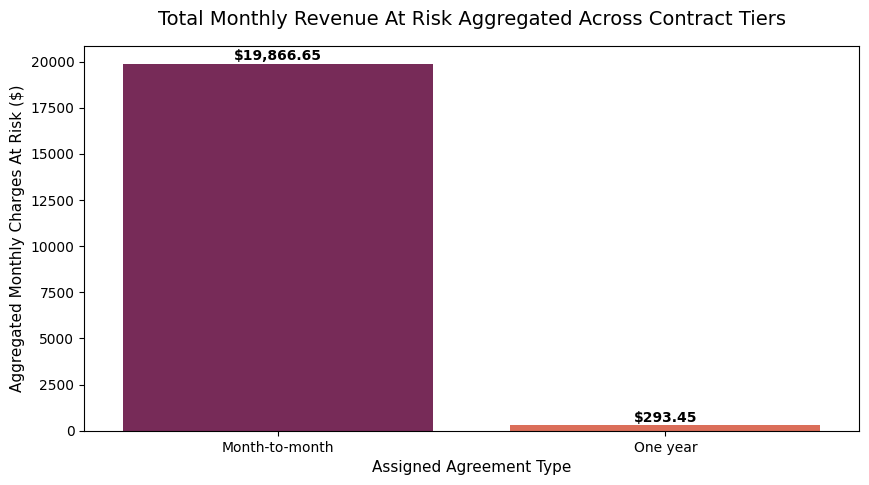

In [26]:
# CONTRACT TIER RISK VOLATILITY SUMMARY
#   Explicitly define best_model and pull it from your trained models dictionary
best_model = models['Random Forest']

#  Filter test dataset rows where the model predicted Churn == 1
X_test_analysis = X_test.copy()
X_test_analysis['Predicted_Churn'] = best_model.predict(X_test)
predicted_churn_data = X_test_analysis[X_test_analysis['Predicted_Churn'] == 1]

#  Sum up monthly revenue losses grouped by Contract type
# (0 = Month-to-month, 1 = One year, 2 = Two year based on LabelEncoder)
contract_revenue_leakage = predicted_churn_data.groupby('Contract')['MonthlyCharges'].sum().reset_index()
contract_revenue_leakage['Contract'] = contract_revenue_leakage['Contract'].map({0: 'Month-to-month', 1: 'One year', 2: 'Two year'})

#  Plot financial contract trends
plt.figure(figsize=(10, 5))
sns.barplot(data=contract_revenue_leakage, x='Contract', y='MonthlyCharges', palette='rocket')

plt.title("Total Monthly Revenue At Risk Aggregated Across Contract Tiers", fontsize=14, pad=15)
plt.xlabel("Assigned Agreement Type", fontsize=11)
plt.ylabel("Aggregated Monthly Charges At Risk ($)", fontsize=11)

for index, row in contract_revenue_leakage.iterrows():
    plt.text(index, row['MonthlyCharges'] + (contract_revenue_leakage['MonthlyCharges'].max() * 0.01),
             f"${row['MonthlyCharges']:,.2f}", ha='center', fontweight='bold')

plt.savefig('contract_tier_revenue_leakage.png')
plt.show()

/tmp/ipykernel_1920/1083174337.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=funnel_values, y=funnel_stages, palette='viridis')


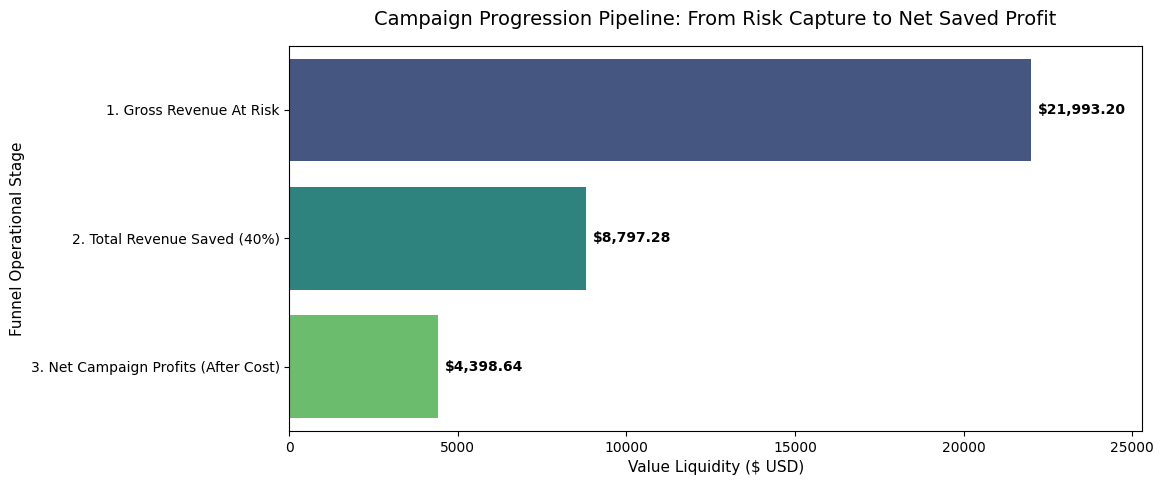

--- ALL 5 STRATEGIC BUSINESS INTELLIGENCE PLOTS COMPLETED AND LOCAL ASSETS GENERATED ---


In [27]:
#  STRATEGIC SAVINGS FUNNEL PROGRESSION
#  Establish sequence benchmarks
funnel_stages = ['1. Gross Revenue At Risk', '2. Total Revenue Saved (40%)', '3. Net Campaign Profits (After Cost)']
funnel_values = [total_revenue_at_risk, revenue_saved, net_retention_roi]

#  Build horizontal progression map
plt.figure(figsize=(11, 5))
sns.barplot(x=funnel_values, y=funnel_stages, palette='viridis')

plt.title("Campaign Progression Pipeline: From Risk Capture to Net Saved Profit", fontsize=14, pad=15)
plt.xlabel("Value Liquidity ($ USD)", fontsize=11)
plt.ylabel("Funnel Operational Stage", fontsize=11)

# Add clear value callouts right next to the funnel tiers
for i, val in enumerate(funnel_values):
    plt.text(val + (max(funnel_values) * 0.01), i, f"${val:,.2f}", va='center', fontweight='bold')

plt.xlim(0, max(funnel_values) * 1.15)
plt.savefig('retention_pipeline_funnel.png')
plt.show()
print("--- ALL 5 STRATEGIC BUSINESS INTELLIGENCE PLOTS COMPLETED AND LOCAL ASSETS GENERATED ---")

In [29]:
#  MODEL SERIALIZATION (SAVING THE BEST MODEL)
import joblib

#  Save the trained Random Forest model to a file
joblib.dump(models['Random Forest'], 'telecom_churn_rf_model.pkl')

#  Save the label encoder to ensure consistent preprocessing during future deployment
joblib.dump(le, 'label_encoder.pkl')

print(" PROJECT COMPLETE: Model and preprocessing pipeline successfully serialized!")
print(" Assets saved as 'telecom_churn_rf_model.pkl' and 'label_encoder.pkl'.")


 PROJECT COMPLETE: Model and preprocessing pipeline successfully serialized!
 Assets saved as 'telecom_churn_rf_model.pkl' and 'label_encoder.pkl'.
